In this notebook, we present our pipeline for analysing the occupation distribution of England and Wales. The data is from the 2021 Census of England and Wales and is maintained by the Office for National Statistics.

In [1]:
import numpy as np, pandas as pd, geopandas as gpd
from tools.core import *
from tools.clustering import *

from scipy.stats import pearsonr, kendalltau
from scipy.spatial.distance import pdist, squareform

import matplotlib as mpl
import matplotlib.pyplot as plt, seaborn as sns

In [31]:
# Raw data (with 'does not apply' column removed)
df_all = pd.read_csv("data/ew_occupations/raw_data.csv", index_col=0)

# The geography
gdf = gpd.read_file("data/ew_occupations/la_shapefile.zip")
gdf = gdf.set_index('LAD24CD').loc[df_all.index][['LAD24NM', 'geometry']]

# Occupations
df_occs = pd.read_csv("data/ew_occupations/df_occs.csv", index_col=0, dtype={'code':str}).set_index('code')

In [32]:
df_occs['population'] = df_all.sum(axis=0)
df_occs['population'] /= df_occs['population'].sum()

gdf['population'] = df_all.sum(axis=1)
gdf['population'] /= gdf['population'].sum()

# Pre-processing

## Tradable Occupations

Identifying occupations producing tradable output.

In [33]:
def get_locational_gini(occ_code):
    rca = ( (df_all[occ_code]/df_all[occ_code].sum()) / gdf['population'] ).to_numpy()
    return np.abs(rca[:, None] - rca).sum() / (318*317*4*rca.mean())

df_occs['loc_gini'] = df_occs.index.map(get_locational_gini)

In [34]:
df_occs['tradability'] = 1. - df_all.apply(lambda x: pearsonr(gdf['population'], x).statistic)

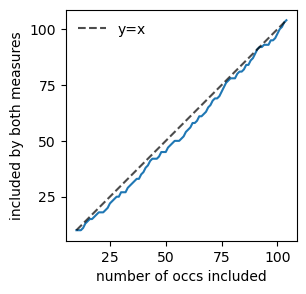

In [10]:
fig, ax = plt.subplots(1,1,figsize=(3, 3))

ax.plot(
    range(10, len(df_occs)+1), 
    [
        len(set(df_occs.sort_values('loc_gini', ascending=False).iloc[:idx].index).intersection(
            set(df_occs.sort_values('tradability', ascending=False).iloc[:idx].index)
        ))
        for idx in range(10, len(df_occs)+1)
    ]
)

ax.plot([10,104], [10,104], '--', c='black', alpha=0.7, label='y=x')
ax.set_xlabel('number of occs included')
ax.set_ylabel('included by both measures')
ax.set_aspect('equal')
ax.set_xticks(range(25, 102, 25))
ax.set_yticks(range(25, 102, 25))
ax.legend(frameon=False)

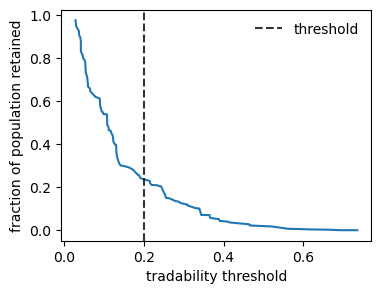

In [11]:
fig, ax = plt.subplots(1,1,figsize=(4, 3))

ax.plot(
    df_occs.sort_values('tradability', ascending=True)['tradability'],
    1 - df_occs.sort_values('tradability', ascending=True)['population'].cumsum()
)
ax.set_xlabel('tradability threshold')
ax.set_ylabel('fraction of population retained')
ax.axvline(0.2, ls='--', label='threshold', color='black', alpha=0.8)
ax.legend(frameon=False)

We set the tradability threshold to 0.2

In [35]:
df_occs[df_occs['tradability']>=0.2]['population'].sum() , (df_occs['tradability']>=0.2).sum()

(0.2421303607369562, 42)

We will also drop 625: Bed and Breakfast and Guest House Owners and Proprietors, which employs 7,354 people, i.e. 0.026% of the workforce

In [36]:
df_occs_trad = df_occs[df_occs['tradability']>=0.2].drop(columns=['tradability', 'loc_gini']).copy()
df_occs_trad = df_occs_trad.drop(index='625')
df_trad = df_all[df_occs_trad.index].copy()

In [37]:
df_occs_trad.loc[:, 'population'] /= df_occs_trad['population'].sum()
gdf['n_population'] = df_trad.sum(axis=1)
gdf['population'] = gdf['n_population'] / gdf['n_population'].sum()
df_vectors = df_trad / df_trad.sum(axis=1).to_numpy()[:, np.newaxis]

## Similarity Matrix

In [43]:
top100_idx = gdf.sort_values('population', ascending=False).head(100).index.tolist()

emb = np.log10( df_vectors.loc[top100_idx] / df_occs_trad['population'] ).to_numpy().T
D = squareform( pdist(emb, metric='euclidean') )

Text(0.5, 0, 'similarity')

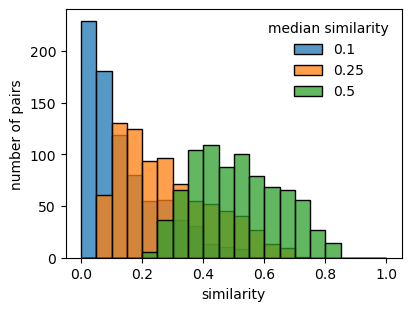

In [17]:
fig, ax = plt.subplots(1,1,figsize=(4, 3), layout='constrained')

for median_sim in [0.1, 0.25, 0.5]:
    tau = -np.log(median_sim)/np.median(D[np.triu_indices_from(D, 1)])
    sns.histplot(
        distance_to_similarity(D, tau=tau)[np.triu_indices_from(D, 1)],
        bins = np.arange(0, 1.01, 0.05),
        ax = ax,
        label = f'{median_sim}'
    )
ax.legend(title='median similarity', frameon=False)
ax.set_ylabel('number of pairs')
ax.set_xlabel('similarity')

We pick median similarity=0.1

In [18]:
tau = -np.log(0.1)/np.median(D[np.triu_indices_from(D, 1)])
Z = distance_to_similarity(D, tau=tau)

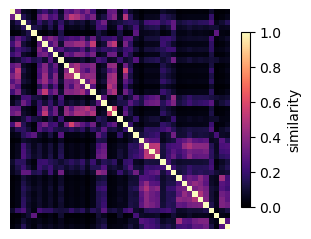

In [19]:
fig, ax = plt.subplots(1,1,figsize=(3, 3), layout='constrained')

plt.colorbar(
    ax.imshow(Z, vmin=0, vmax=1, cmap='magma'), ax=ax, label='similarity', shrink=0.6
)
ax.set_axis_off()

# Analysis

In [2]:
## If you didn't run the pre-processing steps, load the data below


df_vectors = pd.read_csv('outputs/ew_occupations/df_vectors.csv', index_col=0)
Z = np.loadtxt('outputs/ew_occupations/Z.csv', delimiter=',')
D = np.loadtxt('outputs/ew_occupations/D.csv', delimiter=',')
df_occs_trad = pd.read_csv('outputs/ew_occupations/df_occs_trad.csv', index_col=0)
df_trad = pd.read_csv('outputs/ew_occupations/df_trad.csv', index_col=0,)

gdf = gpd.read_file("data/ew_occupations/la_shapefile.zip")
gdf = gdf.set_index('LAD24CD').loc[df_vectors.index][['LAD24NM', 'geometry']]
gdf['n_population'] = df_trad.sum(axis=1)
gdf['population'] = gdf['n_population'] / gdf['n_population'].sum()

In [3]:
## For plotting

def classical_MDS(D, n_components=2, tol=1e-12):
    """
    Classical MDS (Torgerson) from distance matrix D.
    - D: (n,n) numpy array of pairwise distances (finite)
    - n_components: target dimension
    Returns X: (n, n_components) embedding
    """
    n = D.shape[0]
    D2 = D ** 2

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J.dot(D2).dot(J)
    B = (B + B.T) / 2.0

    # eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # keep positive eigenvalues above tol
    positive = eigvals > tol
    if not np.any(positive):
        # all nonpositive: return zeros
        return np.zeros((n, n_components))
    L = np.sqrt(np.maximum(eigvals[positive], 0.0))
    V = eigvecs[:, positive]
    X_full = V * L[np.newaxis, :]   # each column scaled by sqrt(eig)
    if X_full.shape[1] >= n_components:
        X = X_full[:, :n_components]
    else:
        # pad with zeros if fewer positive eigenvalues
        pad = np.zeros((n, n_components - X_full.shape[1]))
        X = np.hstack([X_full, pad])
    return X

pos = classical_MDS(D, 2)
df_occs_trad['x'] = pos[:, 0]
df_occs_trad['y'] = pos[:, 1]

## Entropy and Representativeness

### Entropy

In [4]:
gdf['2_entropy_I'] = get_rao(np.eye(41), df_vectors.to_numpy() )
gdf['2_entropy_Z'] = get_rao(Z, df_vectors.to_numpy() )

In [5]:
kendalltau(gdf['2_entropy_I'], gdf['2_entropy_Z']).statistic

0.6765668710195822

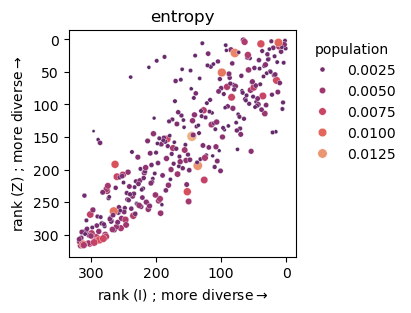

In [6]:
fig, ax = plt.subplots(1,1,figsize=(4, 4), layout='constrained')
sns.scatterplot(
    x = gdf['2_entropy_I'].rank(ascending=False),
    y = gdf['2_entropy_Z'].rank(ascending=False),
    size= gdf['population'], sizes=(5, 50),
    hue = gdf['population'], palette='flare_r', 
    ax=ax,
    legend=True,
)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

ax.set_xlabel('rank (I) ; more diverse' +  r'$\rightarrow$')
ax.set_ylabel('rank (Z) ; more diverse' +  r'$\rightarrow$')
ax.set_title('entropy')

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=False)

### Divergence from population

In [7]:
pop_mean = df_occs_trad['population'].to_numpy()

gdf['2_div_from_pop_I'] = get_sqmahalanobis(np.eye(41), df_vectors.to_numpy(), pop_mean)
gdf['2_div_from_pop_Z'] = get_sqmahalanobis(Z, df_vectors.to_numpy(), pop_mean)

In [8]:
kendalltau(gdf['2_div_from_pop_I'], gdf['2_div_from_pop_Z'])

SignificanceResult(statistic=0.7988214987203143, pvalue=3.2582561634708923e-100)

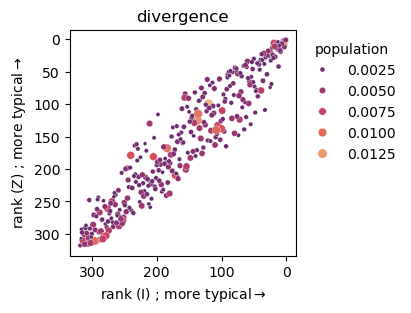

In [9]:
fig, ax = plt.subplots(1,1,figsize=(4, 4), layout='constrained')
sns.scatterplot(
    x = gdf['2_div_from_pop_I'].rank(ascending=True),
    y = gdf['2_div_from_pop_Z'].rank(ascending=True),
    size= gdf['population'], sizes=(5, 50),
    hue = gdf['population'], palette='flare_r', 
    ax=ax,
    legend=True,
)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

ax.set_xlabel('rank (I) ; more typical' +  r'$\rightarrow$')
ax.set_ylabel('rank (Z) ; more typical' +  r'$\rightarrow$')
ax.set_title('divergence')

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=False)

### J-B divergence from each other

In [10]:
def pairwise_jbd_fast(P: np.ndarray, Z: np.ndarray, alpha: float, eps: float = 1e-16, block = None) -> np.ndarray:
    """
    Vectorised all-pairs Jensen-Bregman divergence.
    """
    assert alpha != 1.0
    P = np.asarray(P, dtype=float)
    Z = np.asarray(Z, dtype=float)
    M, N = P.shape
    assert Z.shape == (N, N)

    P = np.maximum(P, eps)
    row_sums = P.sum(axis=1, keepdims=True)
    if np.any(row_sums == 0):
        raise ValueError("Some rows of P sum to zero after clamping.")
    P = P / row_sums

    L = M * (M - 1) // 2
    if L == 0:
        return np.empty((0,), dtype=float)

    # heuristic block
    if block is None:
        approx = int(10_000_000 // max(1, M * N))
        block = max(1, min(M, approx))
    block = int(block)

    ZP = P @ Z
    ZP = np.maximum(ZP, eps) 

    if alpha == 2.0:
        # Quadratic fast branch
        pZp = np.einsum('ij,ij->i', P, ZP)   # (M,)
    else:
        a1 = alpha - 1.0
        ZP_a1 = ZP ** a1
        S_p = np.einsum('ij,ij->i', P, ZP_a1)   # (M,)

    cond = np.empty(L, dtype=float)

    # fill condensed vector in pdist ordering
    for i in range(0, M - 1):
        Pi = P[i]           # (N,)
        ZPi = ZP[i]         # (N,)
        if alpha == 2.0:
            pZp_i = pZp[i]
        else:
            S_p_i = S_p[i]

        j_start = i + 1
        for j0 in range(j_start, M, block):
            j1 = min(M, j0 + block)
            Q = P[j0:j1, :]          # (B, N)
            ZQ = ZP[j0:j1, :]        # (B, N)
            ZQ = np.maximum(ZQ, eps)

            if alpha == 2.0:
                # cross = p^T Z q  (using Z symmetric)
                cross = ZPi @ Q.T                  # (B,)
                pZp_js = pZp[j0:j1]               # (B,)
                # sum-of-divergences = (pZp_i + pZp_j - 2*cross)
                # Jensen-gap (mean divergence) = 0.5 * that.
                J_block = 0.5 * 0.5 * (pZp_i + pZp_js - 2.0 * cross)
                # same as 0.25*(pZp_i + pZp_js - 2*cross)
            else:
                # Zr = 0.5*(ZPi + ZQ) -> (B, N)
                Zr = 0.5 * (ZPi[None, :] + ZQ)
                Zr = np.maximum(Zr, eps)
                Zr_a1 = Zr ** a1

                # r = 0.5*(Pi + Q) -> (B, N)
                r = 0.5 * (Pi[None, :] + Q)

                S_r = np.einsum('ij,ij->i', r, Zr_a1)       # (B,)
                S_q_block = np.einsum('ij,ij->i', Q, ZQ ** a1)  # (B,)

                # Use Jensen-gap formula: (0.5*(S_p_i + S_q) - S_r) / a1
                J_block = (0.5 * (S_p_i + S_q_block) - S_r) / a1

            # store in condensed vector
            start_idx = i * M - (i * (i + 1)) // 2 + (j0 - i - 1)
            cond[start_idx:start_idx + (j1 - j0)] = J_block

    return cond

In [11]:
jbd_i = pd.DataFrame(squareform( pairwise_jbd_fast(df_vectors.to_numpy(), np.eye(41), 2) ), index=gdf.index, columns=gdf.index)
jbd_z = pd.DataFrame(squareform( pairwise_jbd_fast(df_vectors.to_numpy(), Z, 2) ), index=gdf.index, columns=gdf.index)

## Clustering

The clustering results can be stochastic. We include the clusters we report in the paper in the outputs.

In [12]:
c = Clustering.from_vectors(
    vectors=df_vectors.to_numpy(),
    weights=gdf['population'].to_numpy()
)

results = {}
for k in range(2,7):
    results[k] = c.fit(k, Z, 2, n_trials=100, verbose=False, random_seed=42, rel_tol=1e-12, max_iter=500)

In [13]:
c_i = Clustering.from_vectors(
    vectors=df_vectors.to_numpy(),
    weights=gdf['population'].to_numpy()
)

results_i = {}
for k in range(2,7):
    results_i[k] = c_i.fit(k, np.eye(41), 2, n_trials=100, verbose=False, random_seed=42, rel_tol=1e-12, max_iter=500)

In [14]:
from sklearn.metrics import adjusted_mutual_info_score as AMI

(-0.040380136117610946, 1.0)

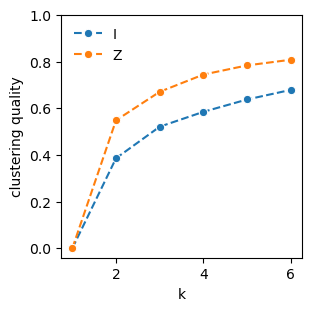

In [15]:
fig, ax = plt.subplots(1,1,figsize=(3,3), layout='constrained')
sns.lineplot(
    x=range(1,7),
    y=[0] + [i[2]/c_i.total_information for i in results_i.values()],
    ls='--', marker='o',
    label='I'
)
sns.lineplot(
    x=range(1,7),
    y=[0] + [i[2]/c.total_information for i in results.values()],
    ls='--', marker='o', 
    label='Z'
)
ax.set_ylabel('clustering quality')
ax.set_xlabel('k')
ax.legend(frameon=False)
ax.set_ylim(None, 1)

(0.0, 1.0)

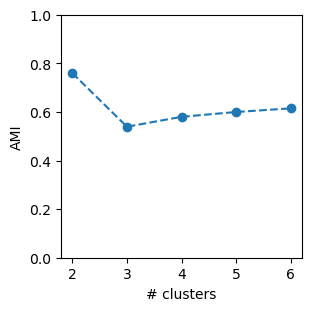

In [16]:
_, ax = plt.subplots(1,1,figsize=(3,3), layout='constrained')
ax.plot(
    range(2,7),
    [AMI(results[k][1], results_i[k][1]) for k in range(2,7)],
    'o--'
)
ax.set_ylabel('AMI')
ax.set_xlabel('# clusters')
ax.set_ylim(0, 1)

In [17]:
def assign_matching(x, y):
    "returns y with cluster ids shuffled to attain the best matching with x, assuming same k"
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics import confusion_matrix

    xid,yid = linear_sum_assignment(-1*confusion_matrix(x,y,labels=range(np.max(x)+1)))
    yid2xid = dict(zip(yid, xid))
    return np.array([yid2xid[_] for _ in y])


def plot_cluster_compare_map(labels1, labels2):
    labels2 = assign_matching(labels1, labels2)

    cmap = dict(enumerate(sns.color_palette('colorblind', as_cmap=True)))
    _, axes = plt.subplots(1,2,figsize=(6, 3), layout='constrained')

    gdf.plot(color=[cmap[i] for i in labels1], ax=axes[0],)
    gdf.plot(color=[cmap[i] for i in labels2], ax=axes[1],)

    gdf.loc[labels1!=labels2].boundary.plot(color='black', ax=axes[1], lw=0.5)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])


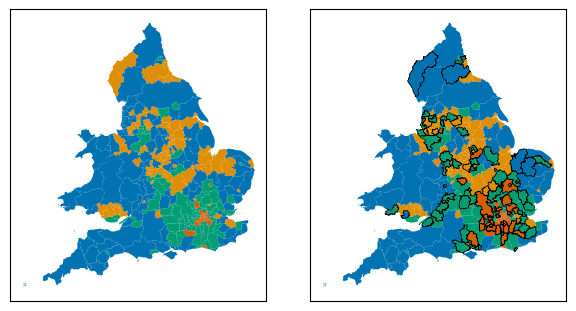

In [18]:
plot_cluster_compare_map(results[4][1], results_i[4][1])

In [19]:
r = Result(df_vectors.to_numpy(), c.weights, Z, 2, results[4][0], results[4][1])

In [20]:
r.describe()

Results of clustering
-----------------
318 distributions of length 41 into 4 clusters.
Fraction of information captured: 0.744
-------------
Cluster 0:
122 points with 0.329 weight.
Within-cluster information=0.089, Between-cluster contribution=0.058
-------------
Cluster 1:
86 points with 0.266 weight.
Within-cluster information=0.077, Between-cluster contribution=0.261
-------------
Cluster 2:
84 points with 0.271 weight.
Within-cluster information=0.061, Between-cluster contribution=0.088
-------------
Cluster 3:
26 points with 0.133 weight.
Within-cluster information=0.029, Between-cluster contribution=0.337


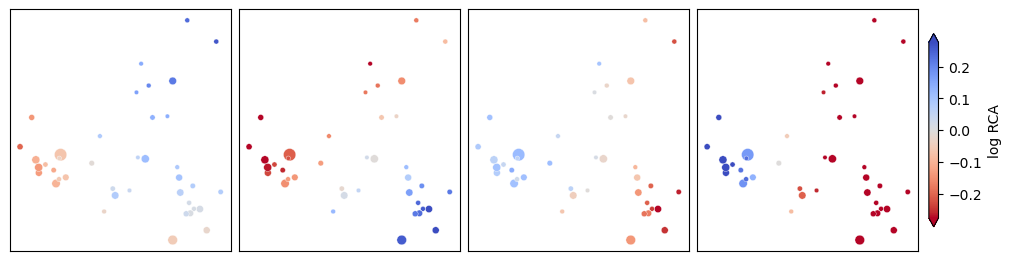

In [21]:
fig, axes = plt.subplots(1,4,figsize=(10, 2.5), layout='constrained')
halfrange = np.quantile(np.abs(np.log10(r.centers/ df_occs_trad['population'].to_numpy())), .8)

for i, ax in enumerate(axes):
    sns.scatterplot(
        df_occs_trad,
        x= 'x', y='y',
        hue= np.log10(r.centers[i] / df_occs_trad['population'].to_numpy()),
        hue_norm = mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),
        palette = 'coolwarm_r',
        size='population', sizes=(10,80),
        legend=False,
        ax= ax,
    )
    ax.set_axis_on()
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])

sm = mpl.cm.ScalarMappable(cmap=sns.color_palette('coolwarm_r',as_cmap=True), norm=mpl.colors.CenteredNorm(vcenter=0., halfrange=halfrange),)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axes[-1], extend='both', shrink=0.8)
cbar.set_label("log RCA")

## Cluster comparison reported in paper

In [22]:
df_rcas_4 = pd.read_csv('outputs/ew_occupations/cluster_rcas_z_4.csv', index_col=0)

df_rcas_4['blue_rank'] = df_rcas_4['blue'].rank(ascending=False)
df_rcas_4['red_rank'] = df_rcas_4['red'].rank(ascending=False)

In [23]:
kendalltau(df_rcas_4['blue'], df_rcas_4['red'])

SignificanceResult(statistic=0.7146341463414634, pvalue=4.644247806358419e-11)

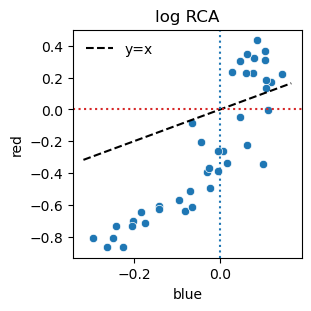

In [24]:
fig, ax = plt.subplots(1,1,figsize=(3,3), layout='constrained')
sns.scatterplot(
    df_rcas_4,
    x = 'blue',
    y = 'red',
    ax=ax
)
#ax.set_aspect('equal')
ax.plot(ax.get_xlim(), ax.get_xlim(), '--', c='black', label='y=x')
ax.axhline(0, ls=':', c=sns.color_palette()[3])
ax.axvline(0, ls=':', c=sns.color_palette()[0])
ax.set_title('log RCA')
ax.legend(frameon=False)